In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import Dataset, DataLoader
from pathlib import Path
import time
import random
from sklearn.model_selection import train_test_split
import os

# ===== Data for Dynamic LNN =====
class UniversalSOHDataset(Dataset):
    def __init__(self, sequences, scaler):
        self.sequences = sequences
        self.scaler = scaler
        
    def __len__(self):
        return len(self.sequences)
    
    def __getitem__(self, idx):
        x_seq, y_seq, battery_id = self.sequences[idx]
        x_scaled = self.scaler.transform(x_seq.reshape(-1, 1)).flatten()
        y_scaled = self.scaler.transform(y_seq.reshape(-1, 1)).flatten()
        return (torch.tensor(x_scaled, dtype=torch.float32), 
                torch.tensor(y_scaled, dtype=torch.float32),
                battery_id)

# ===== Dynamic LNN model =====
class UniversalLNN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100):
        super().__init__()
        
        
        self.encoder = nn.Sequential(
            nn.Linear(input_len, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.Tanh()
        )
        
        
        self.dynamics = LiquidNeuron(hidden_dim)

        
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
            nn.Linear(128, output_len)
        )
        
        
        self.residual_weight = nn.Parameter(torch.tensor(0.1))
        
    def forward(self, x_seq):
        batch_size = x_seq.shape[0]
        device = x_seq.device
        
        x_encoded = self.encoder(x_seq)
        
        self.dynamics.u = x_seq
        
        try:    
            self.dynamics.to(device)
            
            time_steps = 10
            t = torch.linspace(0, 1, time_steps).to(device)
            
            trajectory = odeint(self.dynamics, x_encoded, t, method='euler', rtol=1e-4, atol=1e-6)
            x_dynamic = trajectory[-1]  
            
        except Exception as e:
            # If ODE failed, use fallback
            print(f"⚠️ ODE failed, use fallback: {e}")
            with torch.no_grad():
                x_dynamic = torch.tanh(self.dynamics.W(x_encoded))
        
        # Residual connection
        x_combined = x_dynamic + self.residual_weight * x_encoded
        
        # Decoding
        output = self.decoder(x_combined)
        
        return output

class LiquidNeuron(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.W = nn.Linear(dim, dim, bias=False)
        self.alpha = nn.Parameter(torch.ones(dim) * 0.5)
        self.beta = nn.Parameter(torch.ones(dim) * 0.1)
        
    def forward(self, t, x):
        device = x.device
        
        if hasattr(self, 'u') and self.u is not None:
            u_input = self.u.to(device)
            u_mean = torch.mean(u_input, dim=1, keepdim=True).expand(-1, x.shape[1])
            return -self.alpha.to(device) * x + self.beta.to(device) * torch.tanh(self.W(x) + u_mean)
        else:
            return -self.alpha.to(device) * x + self.beta.to(device) * torch.tanh(self.W(x))

# ------------------------------------Transformers------------------------------------
class UniversalTransformer_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 nhead=4, num_layers=2, dim_feedforward=256, dropout=0.1, pool='mean'):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        self.hidden_dim = hidden_dim
        self.pool = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Positional encoding (learnable)
        self.pos_encoding = nn.Parameter(torch.zeros(1, input_len, hidden_dim))

        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=hidden_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers
        )

        # MLP decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, dim_feedforward),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, output_len)
        )

    def forward(self, x):
        # x: [batch, input_len]
        x = x.unsqueeze(-1)           # → [batch, input_len, 1]
        x = self.embedding(x)         # → [batch, input_len, hidden_dim]
        x = x + self.pos_encoding     # add positional info

        # Transformer encoding
        x_encoded = self.transformer(x)  # → [batch, input_len, hidden_dim]

        # Pooling over the sequence
        if self.pool == 'mean':
            x_pooled = x_encoded.mean(dim=1)  # → [batch, hidden_dim]
        elif self.pool == 'max':
            x_pooled, _ = x_encoded.max(dim=1)
        else:
            # fallback to last token
            x_pooled = x_encoded[:, -1, :]

        # Decode to full output sequence
        out = self.decoder(x_pooled)  # → [batch, output_len]
        return out


# --------------------------------RNN-------------------------------------
class UniversalRNN_SOH(nn.Module):
    def __init__(self, input_len, hidden_dim, output_len, num_layers=2, dropout=0.1):
        super().__init__()

        # Replace LSTM with vanilla RNN
        self.rnn = nn.RNN(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            nonlinearity='tanh'    # default, but explicit
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)   # prunable
        self.fc2 = nn.Linear(hidden_dim, output_len)   # final output (ignore)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(-1)  # (B, T, 1)

        # RNN has only h0, no c0
        h0 = torch.zeros(self.rnn.num_layers, x.size(0), self.rnn.hidden_size, device=x.device)

        out, hn = self.rnn(x, h0)
        h = hn[-1]  # last layer hidden state

        h = self.dropout(torch.relu(self.fc1(h)))
        y = self.fc2(h)
        return y


# ------------------------------------LSTM------------------------------------
class UniversalLSTM_SOH(nn.Module):
    def __init__(self, input_len, hidden_dim, output_len, num_layers=2, dropout=0.1):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True
        )

        self.fc1 = nn.Linear(hidden_dim, hidden_dim)   # prunable
        self.fc2 = nn.Linear(hidden_dim, output_len)   # final output (ignore)

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = x.unsqueeze(-1)
        h0 = torch.zeros(self.lstm.num_layers, x.size(0), self.lstm.hidden_size, device=x.device)
        c0 = torch.zeros_like(h0)

        out, (hn, _) = self.lstm(x, (h0, c0))
        h = hn[-1]

        h = self.dropout(torch.relu(self.fc1(h)))
        y = self.fc2(h)
        return y


 # ------------------------------------GRU------------------------------------
class UniversalGRU_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100, num_layers=2):
        super().__init__()
        self.input_len = input_len
        self.output_len = output_len
        self.hidden_dim = hidden_dim

        # GRU input size = 1 (SOH scalar per time step)
        self.encoder = nn.GRU(
            input_size=1,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.1 if num_layers > 1 else 0
        )

        # Decoder to map hidden state → output sequence
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, output_len)
        )

    def forward(self, x):
        # x: [batch, input_len]
        x = x.unsqueeze(-1)  # → [batch, input_len, 1]
        _, h_last = self.encoder(x)  # h_last: [num_layers, batch, hidden_dim]
        h_last = h_last[-1]          # Take last GRU layer → [batch, hidden_dim]
        out = self.decoder(h_last)   # → [batch, output_len]
        return out
    
# --------------------------------------CNN---------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----- Basic Residual CNN Block -----
class ResidualConv1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, stride=1, dropout=0.05):
        super().__init__()
        padding = (kernel_size - 1) // 2  # preserve sequence length

        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.relu1 = nn.ReLU()
        self.drop1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel_size, stride=stride, padding=padding)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu2 = nn.ReLU()
        self.drop2 = nn.Dropout(dropout)

        # Skip connection
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu1(out)
        out = self.drop1(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu2(out)
        out = self.drop2(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# ----- Full CNN Model -----
class UniversalCNN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 num_blocks=2, kernel_size=5, dropout=0.05, pool='mean'):
        super().__init__()
        self.pool_type = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Build CNN layers
        layers = []
        for i in range(num_blocks):
            in_ch = hidden_dim if i > 0 else hidden_dim
            layers.append(
                ResidualConv1D(in_ch, hidden_dim, kernel_size=kernel_size, dropout=dropout)
            )
        self.cnn = nn.Sequential(*layers)

        # Optional attention pooling
        self.pool = nn.Linear(hidden_dim, 1) if pool == 'attention' else None

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_len)
        )

    def forward(self, x):
        # x: [B, L] → [B, L, 1]
        x = x.unsqueeze(-1)
        x = self.embedding(x)           # [B, L, hidden_dim]
        x = x.transpose(1, 2)           # [B, hidden_dim, L] for Conv1d

        x = self.cnn(x)                 # [B, hidden_dim, L]
        x = x.transpose(1, 2)           # [B, L, hidden_dim] for pooling

        # Pooling over temporal dimension
        if self.pool_type == 'mean':
            x = x.mean(dim=1)
        elif self.pool_type == 'max':
            x, _ = x.max(dim=1)
        elif self.pool_type == 'attention' and self.pool is not None:
            weights = torch.softmax(self.pool(x), dim=1)  # [B, L, 1]
            x = (x * weights).sum(dim=1)
        else:
            x = x[:, -1, :]

        out = self.decoder(x)
        return out

# --------------------------------------TCN----------------------------------------
import torch
import torch.nn as nn
import torch.nn.functional as F

# ----- Chomp1d to trim padding -----
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        if self.chomp_size == 0:
            return x
        return x[:, :, :-self.chomp_size].contiguous()

# ----- Temporal Block with optional multi-scale convs -----
class TemporalBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout=0.05):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        # Multi-scale convolution: kernel_size, kernel_size-2, kernel_size-4 (if >1)
        convs = []
        for k in [kernel_size, max(kernel_size-2,1), max(kernel_size-4,1)]:
            convs.append(
                nn.Conv1d(in_ch, out_ch, k, stride=1, padding=(k-1)*dilation, dilation=dilation)
            )
        self.convs = nn.ModuleList(convs)
        self.chomp = nn.ModuleList([Chomp1d((k-1)*dilation) for k in [kernel_size, max(kernel_size-2,1), max(kernel_size-4,1)]])
        self.bn = nn.BatchNorm1d(out_ch)
        self.relu = nn.ReLU()
        self.drop = nn.Dropout(dropout)

        # Skip connection
        self.downsample = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = 0
        for conv, chomp in zip(self.convs, self.chomp):
            temp = conv(x)
            temp = chomp(temp)
            out += temp
        out = self.bn(out)
        out = self.relu(out)
        out = self.drop(out)

        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)

# ----- Attention Pooling -----
class TemporalAttentionPool(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):  # x: [B, L, H]
        weights = torch.softmax(self.attn(x), dim=1)  # [B, L, 1]
        x_pooled = (x * weights).sum(dim=1)          # [B, H]
        return x_pooled

# ----- Full TCN -----
class UniversalTCN_SOH(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100,
                 num_levels=2, kernel_size=5, dropout=0.05, pool='attention'):
        super().__init__()
        self.pool_type = pool

        # Input embedding: scalar → hidden_dim
        self.embedding = nn.Linear(1, hidden_dim)

        # Build TCN layers with increasing dilation
        layers = []
        for i in range(num_levels):
            dilation = 2 ** i
            in_ch = hidden_dim if i > 0 else hidden_dim
            layers.append(
                TemporalBlock(in_ch, hidden_dim, kernel_size, dilation, dropout)
            )
        self.tcn = nn.Sequential(*layers)

        # Pooling
        if pool == 'attention':
            self.pool = TemporalAttentionPool(hidden_dim)
        else:
            self.pool = None

        # Decoder MLP
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_len)
        )

    def forward(self, x):
        # x: [B, L] → [B, L, 1]
        x = x.unsqueeze(-1)
        x = self.embedding(x)           # [B, L, hidden_dim]
        x = x.transpose(1, 2)           # [B, hidden_dim, L] for Conv1d

        x = self.tcn(x)                 # [B, hidden_dim, L]
        x = x.transpose(1, 2)           # [B, L, hidden_dim] for pooling

        # Pooling over temporal dimension
        if self.pool_type == 'mean':
            x = x.mean(dim=1)
        elif self.pool_type == 'max':
            x, _ = x.max(dim=1)
        elif self.pool_type == 'attention' and self.pool is not None:
            x = self.pool(x)
        else:
            x = x[:, -1, :]

        out = self.decoder(x)
        return out


In [ ]:
# Odeint free model (replaced with Euler step)
# Student model for LNN
class LiquidNeuronCompressed(nn.Module):
    """
    Fast diagonal + low-rank residual ODE replacement.
    Approximates integration with one cheap learned Euler step.
    """
    def __init__(self, dim, rank=12, dt=0.05):
        super().__init__()
        self.dt = dt
        # diagonal weights (O(d))
        self.w_diag = nn.Parameter(torch.randn(dim) * 0.1)
        # low-rank residual (O(d*r))
        self.U = nn.Parameter(torch.randn(dim, rank) * 0.1)
        self.V = nn.Parameter(torch.randn(dim, rank) * 0.1)
        self.alpha = nn.Parameter(torch.ones(dim) * 0.5)
        self.beta  = nn.Parameter(torch.ones(dim) * 0.1)

    def forward(self, x, u=None):
        # Low-rank linear part
        wx = x * self.w_diag            # diagonal term
        if self.U is not None:
            wx += (x @ self.V) @ self.U.T / self.V.size(1)
        if u is not None:
            u_mean = torch.mean(u, dim=1, keepdim=True)
            wx = wx + u_mean.expand_as(wx)

        dx = -self.alpha * x + self.beta * torch.tanh(wx)
        # one learned Euler step
        return x + self.dt * dx

class UniversalLNN_SOH_odefree(nn.Module):
    def __init__(self, input_len=100, hidden_dim=128, output_len=100, rank=None):
        super().__init__()
        if rank==None: rank=hidden_dim
        self.encoder = nn.Sequential(
            nn.Linear(input_len, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, hidden_dim), nn.LayerNorm(hidden_dim), nn.Tanh()
        )
        self.dynamics = LiquidNeuronCompressed(hidden_dim, rank=rank)
        self.decoder = nn.Sequential(
            nn.Linear(hidden_dim, 256), nn.LayerNorm(256), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(256, 128), nn.LayerNorm(128), nn.ReLU(), nn.Linear(128, output_len)
        )
        self.residual_weight = nn.Parameter(torch.tensor(0.1))

    def forward(self, x_seq):
        x_encoded = self.encoder(x_seq)
        # Direct one-step flow instead of odeint
        x_dynamic = self.dynamics(x_encoded, u=x_seq)
        x_combined = x_dynamic + self.residual_weight * x_encoded
        return self.decoder(x_combined)
    


In [3]:
def load_model_and_scaler(model_path, data_dir):

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_class = globals()[f"Universal{model_name}_SOH"] 
    model = model_class(100, 128, 100)  
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device).eval()
    
    files = list(Path(data_dir).glob("Bat*_SOH.xlsx"))[:3]
    all_soh = []
    for f in files:
        try:
            soh = pd.read_excel(f).iloc[:, 0].values
            all_soh.extend(soh[~np.isnan(soh)][::20])  # 每20个取1个
        except: continue
    
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh).reshape(-1, 1))
    return model, scaler, device

# ===== Data loading =====
def load_all_battery_data(data_dir, input_len=100, output_len=100, overlap_ratio=0.8):
    
    data_dir = Path(data_dir)
    file_paths = sorted(data_dir.glob("Bat*_SOH.xlsx"))
    
    all_sequences = []
    battery_info = {}
    
    # Calculate the step length
    step_size = max(1, int((input_len + output_len) * (1 - overlap_ratio)))
    
    print(f" Data loading:")
    print(f"  Input length: {input_len}, Output length: {output_len}")
    print(f"  Overlap ratio: {overlap_ratio*100:.1f}%, Step size: {step_size}")
    print(f"  Find {len(file_paths)} of battery files")
    
    for i, file_path in enumerate(file_paths):
        try:
            # Read data
            df = pd.read_excel(file_path)
            soh_data = df.iloc[:, 0].values
            
            # Cleaning data
            soh_data = soh_data[~np.isnan(soh_data)]  # Remove NaN
            if len(soh_data) < input_len + output_len:
                print(f"  ⚠️  {file_path.name}: The length is not enough: pass")
                continue
            
            # Data Smoothing
            if len(soh_data) > 5:
                from scipy.signal import savgol_filter
                soh_data = savgol_filter(soh_data, window_length=5, polyorder=2)
            
            battery_id = file_path.stem  
            sequence_count = 0
            
            # Generating training series
            for start_idx in range(0, len(soh_data) - input_len - output_len + 1, step_size):
                x_seq = soh_data[start_idx:start_idx + input_len]
                y_seq = soh_data[start_idx + input_len:start_idx + input_len + output_len]
                
                # Quality check
                if (x_seq.min() > 0.5 and x_seq.max() <= 1.1 and 
                    y_seq.min() > 0.5 and y_seq.max() <= 1.1):
                    all_sequences.append((x_seq, y_seq, battery_id))
                    sequence_count += 1
            
            battery_info[battery_id] = {
                'total_cycles': len(soh_data),
                'sequences': sequence_count,
                'soh_range': (soh_data.min(), soh_data.max())
            }
            
            print(f"  ✅ {battery_id}: {len(soh_data)} cycles → {sequence_count} sequences")
            
        except Exception as e:
            print(f"  ❌ Fail to deal with {file_path.name}: {e}")
    
    print(f"\n📈 Data summary:")
    print(f"  Total sereis number: {len(all_sequences)}")
    print(f"  Valid battery number: {len(battery_info)}")
    
    return all_sequences, battery_info

# ===== Train_test split =====
def smart_train_test_split(sequences, test_size=0.2, random_state=42):
    
    # Divide based on battery 
    battery_sequences = {}
    for seq in sequences:
        x, y, battery_id = seq
        if battery_id not in battery_sequences:
            battery_sequences[battery_id] = []
        battery_sequences[battery_id].append(seq)
    
    train_sequences = []
    test_sequences = []
    
    random.seed(random_state)
    
    for battery_id, battery_seqs in battery_sequences.items():
        n_test = max(1, int(len(battery_seqs) * test_size))
        test_indices = random.sample(range(len(battery_seqs)), n_test)
        
        for i, seq in enumerate(battery_seqs):
            if i in test_indices:
                test_sequences.append(seq)
            else:
                train_sequences.append(seq)
    
    print(f"📊 Split results:")
    print(f"  Train dataset: {len(train_sequences)} series")
    print(f"  Test dataset: {len(test_sequences)} series")
    
    return train_sequences, test_sequences



In [10]:
from pathlib import Path
if __name__ == "__main__":
    # Parameters setting
    INPUT_LEN = 100
    OUTPUT_LEN = 100
    HIDDEN_DIM = 128
    BATCH_SIZE = 32
    EPOCHS = 200
    LEARNING_RATE = 1e-3
    OVERLAP_RATIO = 0.8 
    
    # Data direction
    BASE_DIR = Path.cwd().parents[0]  # adjust the index
    data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"
    print("🔬 Universal LNN SOH Predictor")
    print(f"📋 Setting: {INPUT_LEN}→{OUTPUT_LEN}, Hidden layer:{HIDDEN_DIM}, Batch size:{BATCH_SIZE}")
    print(f"🎯 Object: Train the Dynamic LNN with MIT dataset\\n")
    
    # Load data
    print("📁 Loading battery data...")
    try:
        all_sequences, battery_info = load_all_battery_data(
            data_dir, INPUT_LEN, OUTPUT_LEN, OVERLAP_RATIO
        )
        
        if len(all_sequences) == 0:
            raise ValueError("Cannot find the series data")
            
    except Exception as e:
        print(f"❌ Failure on data loading: {e}")
        print("🔄 Generate simulated data (NOT recommended)...")
        
        # Generate simulated data
        all_sequences = []
        for i in range(20):  
            cycles = np.arange(0, 800)
            soh = 1.0 - 0.0002 * cycles - 0.0000005 * cycles**2
            soh += 0.02 * np.sin(cycles * 0.02) + 0.01 * np.random.randn(len(cycles))
            soh = np.clip(soh, 0.8, 1.0)
            
            for j in range(0, len(soh) - INPUT_LEN - OUTPUT_LEN + 1, 20):
                x_seq = soh[j:j+INPUT_LEN]
                y_seq = soh[j+INPUT_LEN:j+INPUT_LEN+OUTPUT_LEN]
                all_sequences.append((x_seq, y_seq, f"SimBat{i:03d}"))
    
    # Pre-process
    print("\\n🔧 Pre processing...")
    all_soh_data = []
    for x_seq, y_seq, _ in all_sequences:
        all_soh_data.extend(x_seq)
        all_soh_data.extend(y_seq)
    
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh_data).reshape(-1, 1))
    print(f"📏 SoH data range: [{np.min(all_soh_data):.3f}, {np.max(all_soh_data):.3f}]")
    
    # Split data
    train_sequences, test_sequences = smart_train_test_split(all_sequences, test_size=0.2)
    
    train_dataset = UniversalSOHDataset(train_sequences, scaler)
    test_dataset = UniversalSOHDataset(test_sequences, scaler)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
    

🔬 Universal LNN SOH Predictor
📋 Setting: 100→100, Hidden layer:128, Batch size:32
🎯 Object: Train the Dynamic LNN with MIT dataset\n
📁 Loading battery data...
 Data loading:
  Input length: 100, Output length: 100
  Overlap ratio: 80.0%, Step size: 39
  Find 124 of battery files
  ✅ Bat001_SOH: 1848 cycles → 43 sequences
  ✅ Bat002_SOH: 2157 cycles → 51 sequences
  ✅ Bat003_SOH: 2234 cycles → 53 sequences
  ✅ Bat004_SOH: 1431 cycles → 32 sequences
  ✅ Bat005_SOH: 1706 cycles → 39 sequences
  ✅ Bat006_SOH: 1071 cycles → 23 sequences
  ✅ Bat007_SOH: 633 cycles → 12 sequences
  ✅ Bat008_SOH: 867 cycles → 18 sequences
  ✅ Bat009_SOH: 1051 cycles → 22 sequences
  ✅ Bat010_SOH: 785 cycles → 16 sequences
  ✅ Bat011_SOH: 877 cycles → 18 sequences
  ✅ Bat012_SOH: 716 cycles → 14 sequences
  ✅ Bat013_SOH: 859 cycles → 17 sequences
  ✅ Bat014_SOH: 854 cycles → 17 sequences
  ✅ Bat015_SOH: 687 cycles → 13 sequences
  ✅ Bat016_SOH: 785 cycles → 16 sequences
  ✅ Bat017_SOH: 531 cycles → 9 sequences


# Model Architechture

In [12]:
model_name = "LSTM"
BASE_DIR = Path.cwd().parents[0]  # adjust the index
data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"
model_path = BASE_DIR/ f"Model Compression All/{model_name}/best_universal_{model_name}_soh.pth"
model, scaler, device = load_model_and_scaler(model_path, data_dir)

print(list(model.named_modules()))
# module = model.encoder
# print(list(module.named_parameters()))
# print(list(module.named_buffers()))

#----------------------------------------------------------------------------
# Torch-Pruning (for actual model size)
# import torch_pruning as tp

# # List everything 
# print(dir(tp)) # module level
# print(dir(tp.pruner)) # submodule level (here pruner is used as example)

# # full library documentation
# help(tp)  
# help(tp.pruner)

[('', UniversalLSTM_SOH(
  (lstm): LSTM(1, 128, num_layers=2, batch_first=True)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=100, bias=True)
  (dropout): Dropout(p=0.1, inplace=False)
)), ('lstm', LSTM(1, 128, num_layers=2, batch_first=True)), ('fc1', Linear(in_features=128, out_features=128, bias=True)), ('fc2', Linear(in_features=128, out_features=100, bias=True)), ('dropout', Dropout(p=0.1, inplace=False))]


In [ ]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torch_pruning as tp
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import copy
import os

# Student models except LNN
# ===== Student Model (Smaller) =====
model_name = "LSTM"
model_class = globals()[f"Universal{model_name}_SOH"]
StudentModel = type(
    "StudentModel",   # class name
    (model_class,),    # tuple of base classes
    {
        "__init__": lambda self, input_len=100, hidden_dim=64, output_len=100: 
            model_class.__init__(self, input_len, hidden_dim, output_len)
    }
)
# Instantiate
model = StudentModel()

        
# ===== Student Model LNN =====
class StudentLNN_ode(UniversalLNN_SOH_odefree):
    def __init__(self, input_len=100, hidden_dim=2, output_len=100):
        super().__init__(input_len, hidden_dim, output_len)


# ===== Student Model GRU =====
class StudentGRU(UniversalGRU_SOH):
    def __init__(self, input_len=100, hidden_dim=64, output_len=100):
        super().__init__(input_len, hidden_dim, output_len)

## Pruning Student model after KD

✅ Model loaded successfully, device: cpu

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

Summary saved to pruning_summary.csv

=== Final Summary ===
  Pruning Type  Total Params  Non-zero Params  Sparsity %        MACs  \
0     original        228580           228580         0.0  20202212.0   
1       gs_0.1        225603           225603         0.0  20199235.0   
2       gs_0.4        216672           216672         0.0  20190304.0   
3       gs_0.2        222626           222626         0.0  20196258.0   
4       gs_0.3        219649           219649         0.0  20193281.0   
5       gs_0.5        213924           213924         0.0  20187556.0   
6       gs_0.6        210947           210947         0.0  20184579.0   
7       gs

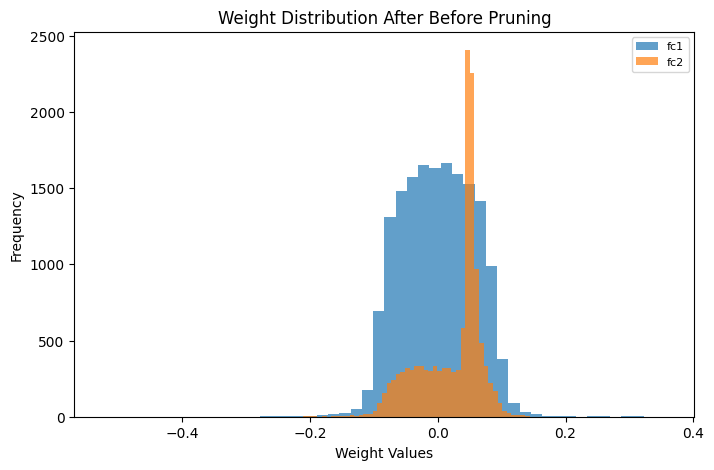

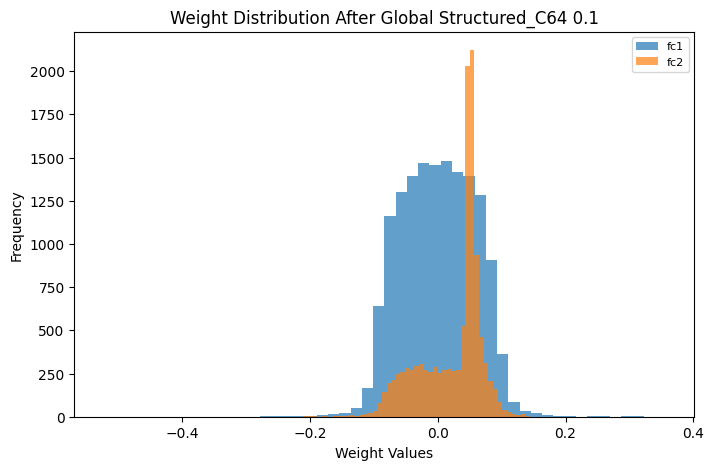

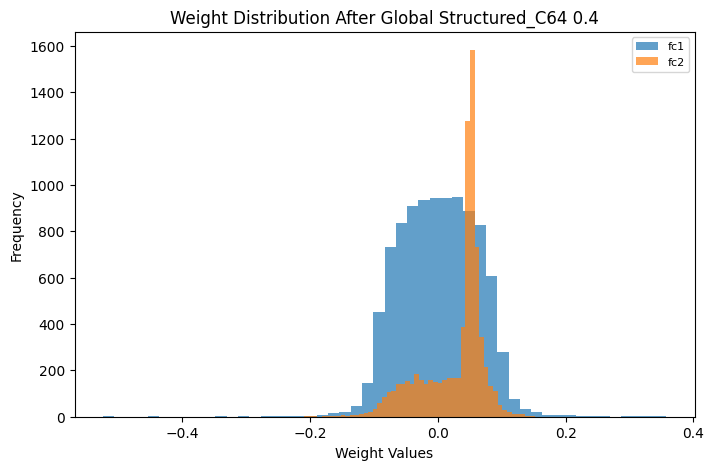

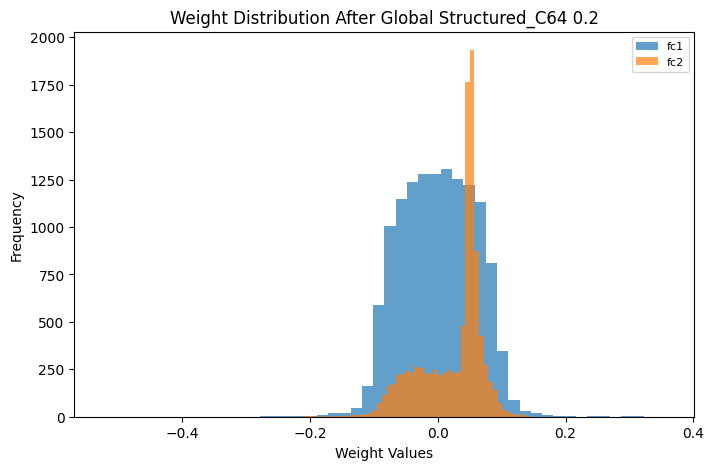

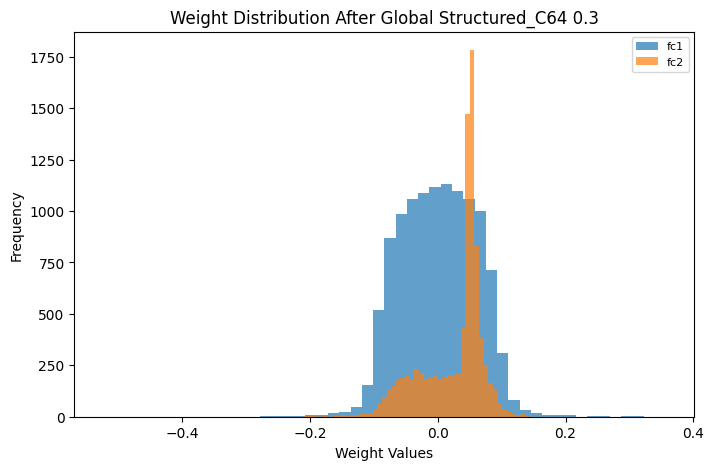

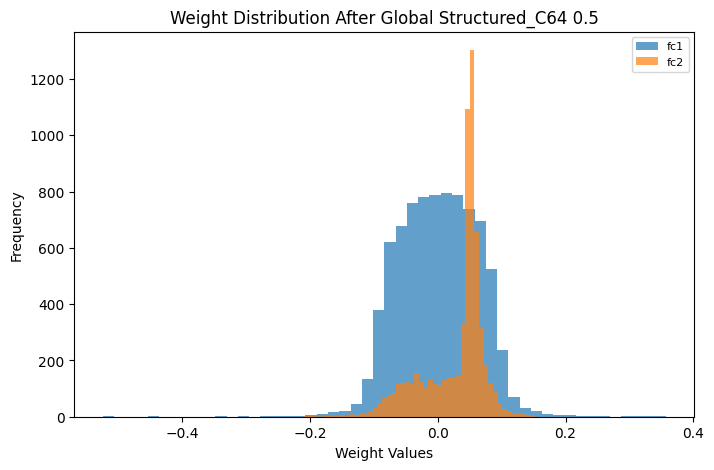

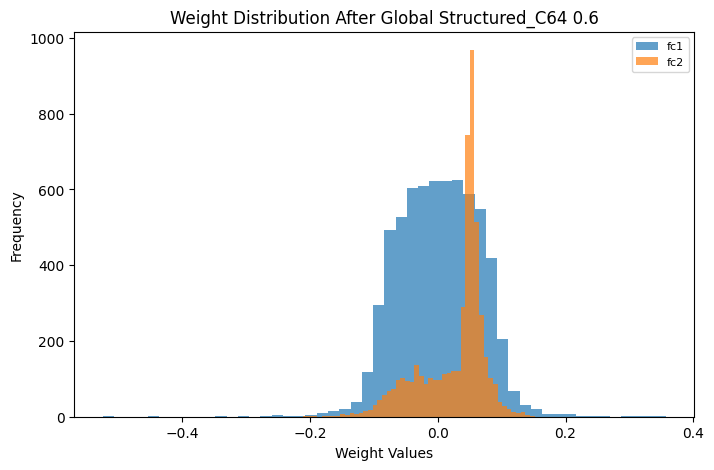

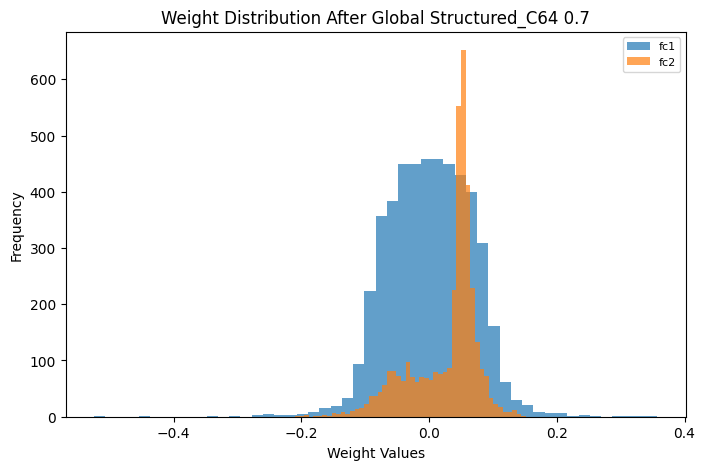

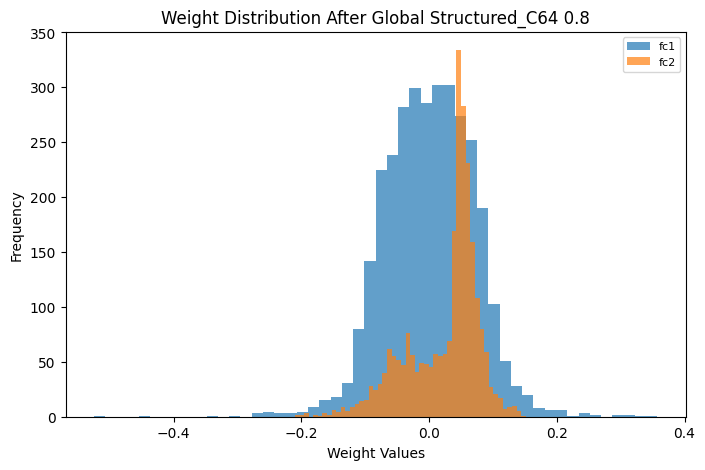

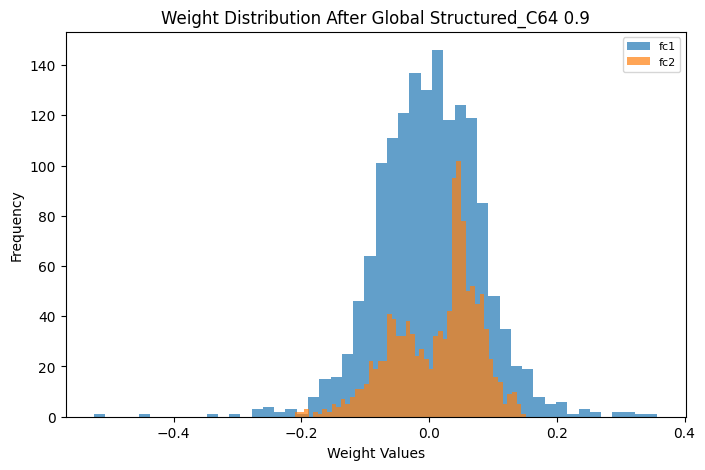

In [ ]:


# Torch-Pruning ref: https://colab.research.google.com/drive/1TRvELQDNj9PwM-EERWbF3IQOyxZeDepp?usp=sharing#scrollTo=Mtp_K1LEUP0y

# --------------------------------Weight distribution plot--------------------------------
def plot_weight_distribution(model, pruning_name):
    plt.figure(figsize=(8, 5))
    colors = plt.cm.tab10(np.linspace(0, 1, 10))
    color_idx = 0
    for name, module in model.named_modules():
        if hasattr(module, 'weight') and module.weight is not None:
            weights = module.weight.detach().cpu().numpy().flatten()
            weights = weights[weights != 0]
            if len(weights) > 0:
                plt.hist(weights, bins=50, alpha=0.7, label=name, color=colors[color_idx % 10])
                color_idx += 1
    plt.title(f"Weight Distribution After {pruning_name}")
    plt.xlabel("Weight Values")
    plt.ylabel("Frequency")
    if color_idx > 0:
        plt.legend(loc='upper right', fontsize=8)
    # plt.show()
    os.makedirs(rf"{model_name}/Pruning/plots", exist_ok=True)
    plt.savefig(f"{model_name}/Pruning/plots/{pruning_name}.png")


# --------------------------------Get model size from file--------------------------------
def get_model_size_from_file(file_path):
    """Get model size in KB directly from the saved file"""
    if os.path.exists(file_path):
        file_size_bytes = os.path.getsize(file_path)
        return file_size_bytes / 1024  # Convert to KB
    return 0


# --------------------------------Stats collection function--------------------------------
def get_sparsity_stats(model, pruning_name, example_inputs, sd_model_file_path=None, full_model_file_path=None):
    total_params = sum(p.numel() for p in model.parameters())
    nonzero_params = sum(torch.count_nonzero(p).item() for p in model.parameters())
    sparsity = 100.0 * (1 - nonzero_params / total_params)

    try:
        macs, nparams = tp.utils.count_ops_and_params(model, example_inputs)
    except:
        macs, nparams = 0, total_params

    in_features, out_features = [], []
    total_in, total_out = 0, 0
    for name, module in model.named_modules():
        if isinstance(module, nn.Linear):
            in_features.append((name, module.in_features))
            out_features.append((name, module.out_features))
            total_in += module.in_features
            total_out += module.out_features

    sd_model_size_kb = get_model_size_from_file(sd_model_file_path)
    full_model_size_kb = get_model_size_from_file(full_model_file_path)


    return {
        "Pruning Type": pruning_name,
        "Total Params": total_params,
        "Non-zero Params": nonzero_params,
        "Sparsity %": round(sparsity, 2),
        "MACs": macs,
        "SD_Model Size (KB)": round(sd_model_size_kb, 2),
        "Full_Model Size (KB)": round(full_model_size_kb, 2),
        "In Features": str(in_features),
        "Out Features": str(out_features),
        "Total In Features": total_in,
        "Total Out Features": total_out,
    }


# --------------------------------Safe copy of model--------------------------------
def safe_model_copy(original_model, device):
    model_copy = copy.deepcopy(original_model)
    return model_copy.to(device)


# --------------------------------Torch-pruning methods--------------------------------
def apply_torch_pruning(pruning_type, model, example_inputs, pruning_ratio=0.2, global_pruning=False):
    # first Linear, last Linear 
    ignored_layers = [model.encoder[0], model.decoder[-1]] # For LNN
    # ignored_layers = [model.encoder, model.decoder[-1]] # For GRU
    # ignored_layers = [model.embedding,model.decoder[-1]] # For Transformer
    # ignored_layers = [model.lstm, model.fc2] # For LSTM
    unwrapped_params = []
    for name, param in model.named_parameters():
        if "weight_ih" in name or "weight_hh" in name:
            # prune along the hidden dimension (first dim)
            unwrapped_params.append((param, 0))  
    if pruning_type == "structured":
        importance = tp.importance.GroupMagnitudeImportance(p=2)
        pruning_name = "Structured Pruning (Torch-Pruning)"
        if global_pruning:
            pruning_name = f"Global Structured_C64 {pruning_ratio}"
    elif pruning_type == "unstructured":
        importance = tp.importance.MagnitudeImportance()
        pruning_name = "Unstructured Pruning (Torch-Pruning)"
    else:
        raise ValueError("Invalid pruning type")

    pruner = tp.pruner.BasePruner(
        model=model,
        example_inputs=example_inputs,
        importance=importance,
        global_pruning=global_pruning,
        pruning_ratio=pruning_ratio,
        ignored_layers=ignored_layers,
        unwrapped_parameters=unwrapped_params
    )
    pruner.step()
    plot_weight_distribution(model, pruning_name)
    return pruning_name

# --------------------------------Main execution--------------------------------
if __name__ == "__main__":
    model_name = "Transformer"
    BASE_DIR = Path.cwd().parents[0]  # adjust the index
    model_path = BASE_DIR / f"Model Compression All/{model_name}/KD/Cos/full_stu_hd64.pth"
    data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"
    
    device = "cpu"
    try:
        model, scaler, device = load_model_and_scaler(model_path, data_dir)
    except:
        model=torch.load(model_path, map_location="cpu", weights_only = False)
    files = list(Path(data_dir).glob("Bat*_SOH.xlsx"))[:3]
    all_soh = []
    for f in files:
        try:
            soh = pd.read_excel(f).iloc[:, 0].values
            all_soh.extend(soh[~np.isnan(soh)][::20])  # 每20个取1个
        except: continue
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh).reshape(-1, 1))

    print(f"✅ Model loaded successfully, device: {device}")
    pruning_ratio = {0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}
    plot_weight_distribution(model, "Before Pruning")
    example_input = torch.randn(1, 100).to(device)
    stats = []
    saved_models = {}
    # Example folder paths
    state_dict_folder = f"{model_name}/Pruning/C64_sd"
    full_model_folder = f"{model_name}/Pruning/C64_full"

    # Make sure folders exist
    os.makedirs(state_dict_folder, exist_ok=True)
    os.makedirs(full_model_folder, exist_ok=True)

    def save_pruned_models(model, example_input, file):
        torch.save(model.state_dict(), os.path.join(state_dict_folder, f"sd_{file}"))
        torch.save(model, os.path.join(full_model_folder, file))
        file_name = os.path.splitext(file)[0]
        stats.append(get_sparsity_stats(model, file_name, example_input, os.path.join(state_dict_folder, f"sd_{file}"), os.path.join(full_model_folder, file)))
        saved_models[file_name] = file

    # Original
    original_file = "original.pth"
    save_pruned_models(model, example_input, original_file)

    for pr in pruning_ratio:
        # Torch-Pruning Global Structured
        m3 = safe_model_copy(model, device)
        name = apply_torch_pruning("structured", m3, example_input, pr, global_pruning=True)
        file3 = f"gs_{pr}.pth"
        save_pruned_models(m3, example_input, file3)
        # Save CSV
        df = pd.DataFrame(stats)
        df.to_csv("pruning_summary.csv", index=False)
        print("\nSummary saved to pruning_summary.csv")

    # Print final summary
    print("\n=== Final Summary ===")
    print(df)
        
    print("\n=== Model File Sizes ===")
    for model_n, file_name in saved_models.items():
        full_path = os.path.join(full_model_folder, file_name)
        size_kb = get_model_size_from_file(full_path)
        print(f"{model_n}: {size_kb:.2f} KB")

# Knowledge Distillation

In [ ]:
import random      
# ===== Distillation =====
def MSE_loss(student_pred, teacher_pred, target, alpha=0.5):
    mse = nn.MSELoss()
    loss_true = mse(student_pred, target)
    loss_kd = mse(student_pred, teacher_pred.detach())
    return alpha * loss_true + (1 - alpha) * loss_kd

def cos_loss(student_pred, teacher_pred, target, alpha=0.5):
    mse = nn.MSELoss()
    cos = nn.CosineEmbeddingLoss()
    loss_true = mse(student_pred, target)          
    ones = torch.ones(student_pred.size(0)).to(student_pred.device)       # target=+1 for "same direction" # cosine similarity loss
    loss_cos = cos(student_pred, teacher_pred.detach(), ones)
    return alpha * loss_true + (1 - alpha) * loss_cos

def get_alpha(epoch, max_epochs, alpha_min=0.1, alpha_max=0.9):
    # linear decay: alpha increases over epochs
    alpha = alpha_min + (alpha_max - alpha_min) * (epoch / max_epochs)
    return alpha

#===========================================================

def train_kd(student, teacher, train_loader, val_loader, epochs=50, lr=1e-3, device='cpu', alpha=0.7):
    student.to(device)
    teacher.to(device)
    teacher.eval()
    optimizer = torch.optim.AdamW(student.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    
    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    for epoch in range(epochs):
        student.train()
        train_loss = 0.0
        alpha = get_alpha(epoch, epochs, alpha_min=0.1, alpha_max=0.9)
        # for x_batch, y_batch, _ in train_loader:
        for batch_idx, (x_batch, y_batch, _) in enumerate(train_loader):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            with torch.no_grad():
                teacher_pred = teacher(x_batch)
            student_pred = student(x_batch)
            if ALPHA.startswith("M"):
                loss = MSE_loss(student_pred, teacher_pred, y_batch, alpha=alpha)
            else:
                loss = cos_loss(student_pred, teacher_pred, y_batch, alpha=alpha)
            if not (torch.isnan(loss) or torch.isinf(loss)):
                loss.backward()
                torch.nn.utils.clip_grad_norm_(student.parameters(), max_norm=1.0)
                optimizer.step()
                train_loss += loss.item()

        student.eval()
        val_loss = 0.0
        with torch.no_grad():
            for x_val, y_val, _ in val_loader:
                teacher_pred = teacher(x_val.to(device))
                student_pred = student(x_val.to(device))
                if ALPHA.startswith("M"):
                    val_loss += MSE_loss(student_pred, teacher_pred, y_val.to(device), alpha=alpha).item()
                else:
                    val_loss += cos_loss(student_pred, teacher_pred, y_val.to(device), alpha=alpha).item()

        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        scheduler.step()

        if avg_val_loss < best_val_loss:
        # if epoch == epochs-1:
            best_val_loss = avg_val_loss
            torch.save(student.state_dict(), rf'{model_name}\KD\{ALPHA}\stu_hd{STU_DIM}.pth')
            torch.save(student, rf'{model_name}\KD\{ALPHA}\full_stu_hd{STU_DIM}.pth')

        if epoch % 10 == 0:
            print(f"[Student] Epoch {epoch:3d} | Train: {avg_train_loss:.6f} | Val: {avg_val_loss:.6f} | LR: {scheduler.get_last_lr()[0]:.6f} | Alpha: {alpha:.6f}")
    return train_losses, val_losses

# ===== Testing =====
def test_universal_model(model, test_sequences, scaler, device, num_examples=3):
    model.eval()
    model.to(device)
    test_samples = random.sample(test_sequences, min(num_examples, len(test_sequences)))
    all_errors = []

    for (x_seq, y_true, _) in test_samples:
        x_scaled = scaler.transform(x_seq.reshape(-1, 1)).flatten()
        x_tensor = torch.tensor(x_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        with torch.no_grad():
            y_pred_scaled= model(x_tensor).cpu().numpy().flatten()
            y_pred = scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
        error = np.abs(y_pred - y_true)
        all_errors.extend(error)

    overall_mae = np.mean(all_errors)
    overall_rmse = np.sqrt(np.mean([e**2 for e in all_errors]))
    print(f"📊 Test results: MAE={overall_mae:.6f}, RMSE={overall_rmse:.6f}")
    return overall_mae, overall_rmse


# ===== Main =====
if __name__ == "__main__":
    # model_name = GRU/ Transformer/ TCN/ LSTM/ LNN
    model_name = "GRU"
    INPUT_LEN, OUTPUT_LEN, HIDDEN_DIM = 100, 100, 128
    BATCH_SIZE, EPOCHS, LEARNING_RATE = 32, 200, 1e-3
    from pathlib import Path

    BASE_DIR = Path.cwd().parents[1]  # adjust the index
    data_dir = BASE_DIR / "Data_for_Main" / "smoothed_soh_excel"
    teacher_path = BASE_DIR / f"Model Compression All/{model_name}/best_universal_{model_name}_soh.pth"

    all_sequences, _ = load_all_battery_data(data_dir, INPUT_LEN, OUTPUT_LEN, 0.8)
    all_soh_data = []
    for x_seq, y_seq, _ in all_sequences:
        all_soh_data.extend(x_seq)
        all_soh_data.extend(y_seq)
    scaler = MinMaxScaler()
    scaler.fit(np.array(all_soh_data).reshape(-1, 1))
    # Split data
    train_sequences, test_sequences = smart_train_test_split(all_sequences, test_size=0.2)
    
    train_dataset = UniversalSOHDataset(train_sequences, scaler)
    test_dataset = UniversalSOHDataset(test_sequences, scaler)
    
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model_class = globals()[f"Universal{model_name}_SOH"] 
    teacher = model_class(100, 128, 100)  
    # teacher = Universal{model_name}_SOH(INPUT_LEN, HIDDEN_DIM, OUTPUT_LEN)
    teacher, scaler, device = load_model_and_scaler(teacher_path, data_dir)

    # --------------1st stage KD---------------------------------
    STU_HIDDEN_DIM= {64, 32, 16, 8, 4, 2}
    ALPHA_VAL = {"MSE", "Cos"}
    for STU_DIM in STU_HIDDEN_DIM:
        for ALPHA in ALPHA_VAL:
            random.seed(42)
            print("🧪 Testing teacher...")
            test_universal_model(teacher, test_sequences, scaler, device)
            print(f"---------STU_DIM : {STU_DIM} , ALPHA : {ALPHA}---------")

            # Train teacher
            os.makedirs(rf"{model_name}\KD\{ALPHA}", exist_ok=True)
            # Train student with KD
            print("\n🚀 Training student with KD...")
            
            try:
                student = StudentModel(INPUT_LEN, STU_DIM, OUTPUT_LEN) # Same as teacher with reduced hidden dimension
                train_kd(student, teacher, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device, alpha=ALPHA)
                student.load_state_dict(torch.load(rf'{model_name}\KD\{ALPHA}\stu_hd{STU_DIM}.pth'))
                print("🧪 Testing student...")
                test_universal_model(student, test_sequences, scaler, device)
            except:
                print(f"mat dim mismatch {STU_DIM}")
        
            
    
    # #--------------Finetuning pruned models---------------------------------
    # STU_HIDDEN_DIM= { 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9}
    # ALPHA_VAL = {"M64", "M32", "M16"}
    # EPOCHS = 20
    # for ALPHA in ALPHA_VAL:
    #     for STU_DIM in STU_HIDDEN_DIM:
    #         pruned_path = BASE_DIR / f"Model Compression All/{model_name}/Pruning/{ALPHA}_full/gs_{STU_DIM}.pth"
    #         random.seed(42)
    #         print("🧪 Testing teacher...")
    #         test_universal_model(teacher, test_sequences, scaler, device)
    #         print(f"---------STU_DIM : {STU_DIM} , ALPHA : {ALPHA}---------")

    #         # Train teacher
    #         os.makedirs(rf"{model_name}\KD\{ALPHA}", exist_ok=True)
    #         # Train student with KD
    #         print("\n🚀 Training student with KD...")
    #         student = torch.load(pruned_path, map_location="cuda", weights_only=False)
    #         try:
    #             train_kd(student, teacher, train_loader, test_loader, epochs=EPOCHS, lr=LEARNING_RATE, device=device, alpha=ALPHA)
    #             student.load_state_dict(torch.load(rf'{model_name}\KD\{ALPHA}\stu_hd{STU_DIM}.pth'))
    #             print("🧪 Testing student...")
    #             test_universal_model(student, test_sequences, scaler, device)
    #         except:
    #             print(f"mat dim mismatch {STU_DIM}")
        



 Data loading:
  Input length: 100, Output length: 100
  Overlap ratio: 80.0%, Step size: 39
  Find 124 of battery files
  ✅ Bat001_SOH: 1848 cycles → 43 sequences
  ✅ Bat002_SOH: 2157 cycles → 51 sequences
  ✅ Bat003_SOH: 2234 cycles → 53 sequences
  ✅ Bat004_SOH: 1431 cycles → 32 sequences
  ✅ Bat005_SOH: 1706 cycles → 39 sequences
  ✅ Bat006_SOH: 1071 cycles → 23 sequences
  ✅ Bat007_SOH: 633 cycles → 12 sequences
  ✅ Bat008_SOH: 867 cycles → 18 sequences
  ✅ Bat009_SOH: 1051 cycles → 22 sequences
  ✅ Bat010_SOH: 785 cycles → 16 sequences
  ✅ Bat011_SOH: 877 cycles → 18 sequences
  ✅ Bat012_SOH: 716 cycles → 14 sequences
  ✅ Bat013_SOH: 859 cycles → 17 sequences
  ✅ Bat014_SOH: 854 cycles → 17 sequences
  ✅ Bat015_SOH: 687 cycles → 13 sequences
  ✅ Bat016_SOH: 785 cycles → 16 sequences
  ✅ Bat017_SOH: 531 cycles → 9 sequences
  ✅ Bat018_SOH: 556 cycles → 10 sequences
  ✅ Bat019_SOH: 1011 cycles → 21 sequences
  ✅ Bat020_SOH: 1014 cycles → 21 sequences
  ✅ Bat021_SOH: 851 cycles → 17

In [ ]:
# convert_tflite_to_c.py for Arduino Nano Deployment
model_name = "LNN"
tflite_model_path = BASE_DIR / f"Model Compression All/{model_name}/model.tflite"
header_file_path = "model.h"

with open(tflite_model_path, "rb") as f:
    data = f.read()

with open(header_file_path, "w") as f:
    f.write(f"unsigned char gmodel[] = {{\n")
    for i, byte in enumerate(data):
        if i % 12 == 0:
            f.write("\n    ")
        f.write(f"0x{byte:02x}, ")
    f.write(f"\n}};\n")
    f.write(f"unsigned int gmodel_len = {len(data)};\n")

print(f"✅ Converted {tflite_model_path} to {header_file_path}")

In [ ]:
import torch
model_name = "CNN"
model_path = BASE_DIR / f"Model Compression All/{model_name}/best_universal_{model_name}_soh.pth"
data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"
try: model, scaler, device = load_model_and_scaler(model_path, data_dir)
except: model=torch.load(model_path, map_location="cpu", weights_only = False)      
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 358884
Trainable parameters: 358884


In [ ]:

from fvcore.nn import FlopCountAnalysis
import torch
MODELS = {"CNN", "TCN", "RNN", "LSTM", "GRU", "Transformer", "LNN"}
MODELS = {"-"}
for model_name in MODELS:
    model_path = BASE_DIR / f"Model Compression All/{model_name}/best_universal_{model_name}_soh.pth"
    # model_path = BASE_DIR / f"Model Compression All/{model_name}/{model_name}_optimal.pth"
    data_dir = BASE_DIR / "Data_for_Main/smoothed_soh_excel"
    # model, scaler, device = load_model_and_scaler(model_path, data_dir)
    model=torch.load(model_path, map_location="cuda", weights_only = False) 
    model.eval()
    input_len=100
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    dummy = torch.randn(1, input_len).to(device)
    flops = FlopCountAnalysis(model, dummy)

    print(f"{model_name} FLOPs:", flops.total()/1e6)

    #Quantization has no impact on FLOPS. Since measurinf FLOPS in TFlite is not  well supported, we use the Final compressed model from Pytorch for evaluating.


Unsupported operator aten::tanh encountered 2 time(s)
Unsupported operator aten::mul encountered 5 time(s)
Unsupported operator aten::numpy_T encountered 1 time(s)
Unsupported operator aten::div encountered 1 time(s)
Unsupported operator aten::add_ encountered 1 time(s)
Unsupported operator aten::mean encountered 1 time(s)
Unsupported operator aten::expand_as encountered 1 time(s)
Unsupported operator aten::add encountered 4 time(s)
Unsupported operator aten::neg encountered 1 time(s)


- FLOPs: 0.067909
